In [5]:
import scipy.io
import os
import sys
import h5py
import numpy as np
from scipy.interpolate import interp1d
import torch
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sbi import utils as sbi_utils
from sbi.inference import SNPE
from sbi.utils.get_nn_models import posterior_nn
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import random

# Set seeds for reproducibility
random.seed(42)
np.random.seed(42)
os.environ['TF_DETERMINISTIC_OPS'] = '1'

# --- 1. Data Loading and Initial Processing ---

# (Assuming all function definitions and file loading from your original code are here)
# ... (load_h5_data, load_mat_data, resample_and_smooth, process_data, etc.) ...
name_format = "GBM_Hist_run30_new"
print("Note: use results30.mat which has 10000 datasets; B only has positive Z values; 100, 0.12, 14")
file_path = os.path.join('MATLAB_DATA', 'results33.mat')  # Replace with your actual file path
def generate_filename(base_name, extension):
    return f"{name_format}_{base_name}.{extension}"



h5_file_numbers = {3, 6, 7, 9}


# Function to load data from .h5 file
def load_h5_data(file_path):
    with h5py.File(file_path, 'r') as hdf:
        results_group = hdf['results']
        B_MAG_refs = results_group['B_MAG'][()]
        EDC_MAG_refs = results_group['EDC_MAG'][()]
        X_refs = results_group['X'][()]
        I_refs = results_group['I'][()]
        B_MAG_raw = [hdf[ref][()] for ref in B_MAG_refs.flatten()]
        EDC_MAG_raw = [hdf[ref][()] for ref in EDC_MAG_refs.flatten()]
        X_raw = [hdf[ref][()] for ref in X_refs.flatten()]
        I_raw = [hdf[ref][()] for ref in I_refs.flatten()]
    return B_MAG_raw, EDC_MAG_raw, X_raw, I_raw


# Function to load data from .mat file
def load_mat_data(file_path):
    mat_contents = scipy.io.loadmat(file_path)
    results = mat_contents['results']
    B_MAG_raw = [result['B_MAG'][0] for result in results[0]]
    EDC_MAG_raw = [result['EDC_MAG'][0] for result in results[0]]
    X_raw = [result['X'][0] for result in results[0]]  # Scaling X values
    I_raw = [result['I'][0] for result in results[0]]
    return B_MAG_raw, EDC_MAG_raw, X_raw, I_raw


# Function to resample and smooth data
def resample_and_smooth(X, I, new_length):
    X_new = np.linspace(6562.3, 6563.3, num=new_length)
    f = interp1d(X, I, kind='cubic', fill_value="extrapolate")
    I_new = f(X_new)
    return X_new, I_new


# Function to process data
def process_data(B_MAG_raw, EDC_MAG_raw, X_raw, I_raw, fixed_length=1200):
    X_data, I_data, B_MAG_data, EDC_MAG_data = [], [], [], []
    for i in range(len(X_raw)):
        X = np.squeeze(X_raw[i])
        I = np.squeeze(I_raw[i])
        B = np.squeeze(B_MAG_raw[i])
        EDC = np.squeeze(EDC_MAG_raw[i])
        X_scaled = X * 10**10
        X_resampled, I_resampled = resample_and_smooth(X_scaled, I, fixed_length)
        X_data.append(X_resampled)
        I_data.append(I_resampled)
        B_MAG_data.append(B)
        EDC_MAG_data.append(EDC)
    return np.array(B_MAG_data), np.array(EDC_MAG_data), np.array(X_data), np.array(I_data)

# Main function to determine the type of file and load data accordingly
def load_and_process_file(file_path):
    file_name = os.path.basename(file_path)
    
    # Extract the file number (e.g., results1, results5, etc.)
    file_number = int(file_name.lstrip('results').rstrip('.mat'))
    
    if file_number in h5_file_numbers:
        # It's an HDF5 file
        print(f"Processing {file_name} as an HDF5 file...", flush=True)
        B_MAG_raw, EDC_MAG_raw, X_raw, I_raw = load_h5_data(file_path)
    else:
        # It's a standard .mat file
        print(f"Processing {file_name} as a .mat file...", flush=True)
        B_MAG_raw, EDC_MAG_raw, X_raw, I_raw = load_mat_data(file_path)
    
    # Process the loaded data
    B_MAG_data, EDC_MAG_data, X_data, I_data = process_data(B_MAG_raw, EDC_MAG_raw, X_raw, I_raw)
    
    return B_MAG_data, EDC_MAG_data, X_data, I_data
    
B_MAG_data, EDC_MAG_data, X_data, I_data = load_and_process_file(file_path)
print("Data loading and resampling completed.")

# Combine target variables before splitting
target_data_raw = np.column_stack((
    B_MAG_data[:, 2], 
    EDC_MAG_data[:, 0], 
    EDC_MAG_data[:, 1], 
    EDC_MAG_data[:, 2]
))
input_data_raw = I_data

# --- 2. Train-Test Split (IMPORTANT: Split *before* normalization/scaling) ---
input_train_raw, input_test_raw, target_train_raw, target_test_raw = train_test_split(
    input_data_raw, target_data_raw, test_size=0.2, random_state=42
)

print(f"Data split into {len(input_train_raw)} training samples and {len(input_test_raw)} testing samples.")

# --- 3. Input Data Preprocessing (Z-Score Normalization) ---

# Calculate std dev for filtering *only* from the training set
stds_train = np.std(input_train_raw, axis=0)
start_index = 0
end_index = input_train_raw.shape[1] - 1

for i in range(input_train_raw.shape[1]):
    if stds_train[i] >= 0.01:
        start_index = i
        break
for i in range(input_train_raw.shape[1] - 1, -1, -1):
    if stds_train[i] >= 0.01:
        end_index = i
        break

print(f"Input data will be filtered from column {start_index} to {end_index} based on training set variance.")

# Apply the same filtering to both train and test sets
I_train_filtered = input_train_raw[:, start_index:end_index + 1]
I_test_filtered = input_test_raw[:, start_index:end_index + 1]

# Calculate mean and std for normalization *only* from the filtered training set
means_train_filtered = np.mean(I_train_filtered, axis=0)
stds_train_filtered = np.std(I_train_filtered, axis=0)

# Normalize the training data
normalized_I_train = (I_train_filtered - means_train_filtered) / stds_train_filtered
# Normalize the testing data *using parameters from the training data*
normalized_I_test = (I_test_filtered - means_train_filtered) / stds_train_filtered

# Final interpolation to ensure fixed length (e.g., 1200) after filtering
def interpolate_to_fixed_length(data, new_length=1200):
    resampled_data = []
    for row in data:
        x_original = np.linspace(0, 1, num=len(row))
        x_new = np.linspace(0, 1, num=new_length)
        f = interp1d(x_original, row, kind='cubic', fill_value="extrapolate")
        resampled_data.append(f(x_new))
    return np.array(resampled_data)

input_data_train = interpolate_to_fixed_length(normalized_I_train)
input_data_test = interpolate_to_fixed_length(normalized_I_test)

print("Input (z-score) preprocessing complete.")

# --- 4. Target Data Preprocessing (MinMax Scaling) ---

# Separate the components for both train and test sets before scaling
B3_train = target_train_raw[:, 0].reshape(-1, 1)
E1_train = target_train_raw[:, 1].reshape(-1, 1)
E2_train = target_train_raw[:, 2].reshape(-1, 1)
E3_train = target_train_raw[:, 3].reshape(-1, 1)

B3_test = target_test_raw[:, 0].reshape(-1, 1)
E1_test = target_test_raw[:, 1].reshape(-1, 1)
E2_test = target_test_raw[:, 2].reshape(-1, 1)
E3_test = target_test_raw[:, 3].reshape(-1, 1)

# Initialize a separate scaler for each component
scaler_B3 = MinMaxScaler(feature_range=(0, 1))
scaler_E1 = MinMaxScaler(feature_range=(0, 1))
scaler_E2 = MinMaxScaler(feature_range=(0, 1))
scaler_E3 = MinMaxScaler(feature_range=(0, 1))

# Fit and transform the TRAINING data
B3_train_scaled = scaler_B3.fit_transform(B3_train)
E1_train_scaled = scaler_E1.fit_transform(E1_train)
E2_train_scaled = scaler_E2.fit_transform(E2_train)
E3_train_scaled = scaler_E3.fit_transform(E3_train)

# ONLY transform the TESTING data (using the scalers fit on the training data)
B3_test_scaled = scaler_B3.transform(B3_test)
E1_test_scaled = scaler_E1.transform(E1_test)
E2_test_scaled = scaler_E2.transform(E2_test)
E3_test_scaled = scaler_E3.transform(E3_test)

# Recombine the scaled components into the final target data arrays
target_data_train = np.hstack((B3_train_scaled, E1_train_scaled, E2_train_scaled, E3_train_scaled))
target_data_test = np.hstack((B3_test_scaled, E1_test_scaled, E2_test_scaled, E3_test_scaled))


print("Data organized.", flush=True)

<frozen importlib._bootstrap>:219: RuntimeWarning: scipy._lib.messagestream.MessageStream size changed, may indicate binary incompatibility. Expected 56 from C header, got 64 from PyObject


Note: use results30.mat which has 10000 datasets; B only has positive Z values; 100, 0.12, 14
Processing results33.mat as a .mat file...
Data loading and resampling completed.
Data split into 8000 training samples and 2000 testing samples.
Input data will be filtered from column 363 to 864 based on training set variance.
Input (z-score) preprocessing complete.
Data organized.


In [6]:
from sklearn.experimental import enable_hist_gradient_boosting  
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor

/home/botingl/miniconda3/envs/tensor/lib/python3.8/site-packages/sklearn/experimental/enable_hist_gradient_boosting.py:15: UserWarning: Since version 1.0, it is not needed to import enable_hist_gradient_boosting anymore. HistGradientBoostingClassifier and HistGradientBoostingRegressor are now stable and can be normally imported from sklearn.ensemble.
  warnings.warn(


In [7]:
gbm = HistGradientBoostingRegressor(
    max_iter=100,            # Maximum number of boosting iterations
    learning_rate=0.12,      # Learning rate
    max_depth=14,             # Maximum depth of the tree
    validation_fraction=0.2, # Fraction of the data to use for validation
    early_stopping=True,     # Early stopping flag
    tol=1e-4,                # Tolerance for stopping
    verbose=1,                # To monitor the training process
    random_state=42,
    loss='squared_error'
)

In [8]:
multi_gbm = MultiOutputRegressor(gbm)

In [9]:
import joblib

In [10]:
# Define the path where the model was saved
model_load_path = os.path.join("/home/botingl/machine learning copy", generate_filename("trained_multioutput_gbm_model", "joblib"))

In [11]:
# Load the model using joblib
model = joblib.load(model_load_path)
print(f"Model loaded from {model_load_path}")

Model loaded from /home/botingl/machine learning copy/GBM_Hist_run30_new_trained_multioutput_gbm_model.joblib


In [12]:
# Whole model evaluation (NMSE, rMAE, R²)
def evaluate_whole_model(y_true, y_pred):
    nmse = mean_squared_error(y_true, y_pred) / np.var(y_true)
    rmae = mean_absolute_error(y_true, y_pred) / np.mean(np.abs(y_true))
    r2 = r2_score(y_true, y_pred)
    return nmse, rmae, r2

In [13]:
# Component-wise evaluation (MSE, MAE, R²)
def evaluate_components(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return mse, mae, r2

In [14]:
# Evaluation metrics for the training data
print("Start to evaluate the training set.", flush=True)
size = len(input_data_train) if len(input_data_train) < 8000 else 8000
train_subset_indices = np.random.choice(len(input_data_train), size=size, replace=False)
train_input_data_subset = input_data_train[train_subset_indices]
train_target_data_subset = target_data_train[train_subset_indices]

Start to evaluate the training set.


In [15]:
predictions_train = model.predict(train_input_data_subset)

In [16]:
num_input = len(train_input_data_subset)

In [17]:
# Scale back the predicted values to original range
B_pred_train = scaler_B3.inverse_transform(predictions_train[:, 0].reshape(-1, 1))
E_pred_train = np.column_stack((
    scaler_E1.inverse_transform(predictions_train[:, 1].reshape(-1, 1)),
    scaler_E2.inverse_transform(predictions_train[:, 2].reshape(-1, 1)),
    scaler_E3.inverse_transform(predictions_train[:, 3].reshape(-1, 1))
))

In [18]:
# Scale back the true values to original range
B_true_train = scaler_B3.inverse_transform(train_target_data_subset[:, 0].reshape(-1, 1))
E_true_train = np.column_stack((
    scaler_E1.inverse_transform(train_target_data_subset[:, 1].reshape(-1, 1)),
    scaler_E2.inverse_transform(train_target_data_subset[:, 2].reshape(-1, 1)),
    scaler_E3.inverse_transform(train_target_data_subset[:, 3].reshape(-1, 1))
))

In [19]:
# Combine the scaled-back true and predicted values for evaluation
true_train_combined = np.column_stack((B_true_train, E_true_train))
pred_train_combined = np.column_stack((B_pred_train, E_pred_train))

In [20]:
# Whole model evaluation
nmse_train, rmae_train, r2_whole_model_train = evaluate_whole_model(true_train_combined, pred_train_combined)
print(f"Whole Model NMSE: {nmse_train}, rMAE: {rmae_train}, R²: {r2_whole_model_train}")

Whole Model NMSE: 0.012315210317234903, rMAE: 0.05822166872451783, R²: 0.9830478281432992


In [21]:
# Component-wise evaluation
mse_train_B3, mae_train_B3, r2_train_B3 = evaluate_components(B_true_train, B_pred_train)
mse_train_E1, mae_train_E1, r2_train_E1 = evaluate_components(E_true_train[:, 0], E_pred_train[:, 0])
mse_train_E2, mae_train_E2, r2_train_E2 = evaluate_components(E_true_train[:, 1], E_pred_train[:, 1])
mse_train_E3, mae_train_E3, r2_train_E3 = evaluate_components(E_true_train[:, 2], E_pred_train[:, 2])

In [22]:
# Output the evaluation for each component
print(f"B3: MSE = {mse_train_B3}, MAE = {mae_train_B3}, R² = {r2_train_B3}")
print(f"E1: MSE = {mse_train_E1}, MAE = {mae_train_E1}, R² = {r2_train_E1}")
print(f"E2: MSE = {mse_train_E2}, MAE = {mae_train_E2}, R² = {r2_train_E2}")
print(f"E3: MSE = {mse_train_E3}, MAE = {mae_train_E3}, R² = {r2_train_E3}")

B3: MSE = 2.7812737650226085e-05, MAE = 0.003936523206883682, R² = 0.9962720449303734
E1: MSE = 604.7196330156067, MAE = 16.99794051165502, R² = 0.9715433434312463
E2: MSE = 262.29767141292996, MAE = 12.067669985032856, R² = 0.9873882934195938
E3: MSE = 480.00730234843553, MAE = 14.442116497641207, R² = 0.9769876307919834


In [23]:
# Save evaluation metrics to a text file
metrics_train_file = os.path.join("/home/botingl/machine learning copy", generate_filename("evaluation_metrics_train", "txt"))
with open(metrics_train_file, "w") as f:
    f.write(f"Whole Model: NMSE: {nmse_train}, rMAE: {rmae_train}, R²: {r2_whole_model_train}\n")
    f.write(f"B3: MSE = {mse_train_B3}, MAE = {mae_train_B3}, R² = {r2_train_B3}\n")
    f.write(f"E1: MSE = {mse_train_E1}, MAE = {mae_train_E1}, R² = {r2_train_E1}\n")
    f.write(f"E2: MSE = {mse_train_E2}, MAE = {mae_train_E2}, R² = {r2_train_E2}\n")
    f.write(f"E3: MSE = {mse_train_E3}, MAE = {mae_train_E3}, R² = {r2_train_E3}\n")

In [24]:
print("Training set evaluation done.", flush=True)

Training set evaluation done.


In [25]:
# Evaluate the model on the testing set
print("Start to evaluate the testing set.", flush=True)

Start to evaluate the testing set.


In [26]:
predictions_test = model.predict(input_data_test)

In [27]:
# Scale back the predicted values to original range for the test data
B_pred_test = scaler_B3.inverse_transform(predictions_test[:, 0].reshape(-1, 1))

In [28]:
E_pred_test = np.column_stack((
    scaler_E1.inverse_transform(predictions_test[:, 1].reshape(-1, 1)),
    scaler_E2.inverse_transform(predictions_test[:, 2].reshape(-1, 1)),
    scaler_E3.inverse_transform(predictions_test[:, 3].reshape(-1, 1))
))

In [29]:
# Scale back the true values to original range for the test data
B_true_test = scaler_B3.inverse_transform(target_data_test[:, 0].reshape(-1, 1))

In [30]:
E_true_test = np.column_stack((
    scaler_E1.inverse_transform(target_data_test[:, 1].reshape(-1, 1)),
    scaler_E2.inverse_transform(target_data_test[:, 2].reshape(-1, 1)),
    scaler_E3.inverse_transform(target_data_test[:, 3].reshape(-1, 1))
))

In [31]:
# Combine the scaled-back true and predicted values for evaluation (test data)
true_test_combined = np.column_stack((B_true_test, E_true_test))
pred_test_combined = np.column_stack((B_pred_test, E_pred_test))

In [32]:
# Whole model evaluation
nmse_test, rmae_test, r2_whole_model_test = evaluate_whole_model(true_test_combined, pred_test_combined)
print(f"Whole Model NMSE: {nmse_test}, rMAE: {rmae_test}, R²: {r2_whole_model_test}")

Whole Model NMSE: 0.029079160032190885, rMAE: 0.08651701482217763, R²: 0.9604630355072175


In [33]:
# Component-wise evaluation
mse_test_B3, mae_test_B3, r2_test_B3 = evaluate_components(B_true_test, B_pred_test)
mse_test_E1, mae_test_E1, r2_test_E1 = evaluate_components(E_true_test[:, 0], E_pred_test[:, 0])
mse_test_E2, mae_test_E2, r2_test_E2 = evaluate_components(E_true_test[:, 1], E_pred_test[:, 1])
mse_test_E3, mae_test_E3, r2_test_E3 = evaluate_components(E_true_test[:, 2], E_pred_test[:, 2])

In [34]:
# Output the evaluation for each component
print(f"B3: MSE = {mse_test_B3}, MAE = {mae_test_B3}, R² = {r2_test_B3}")
print(f"E1: MSE = {mse_test_E1}, MAE = {mae_test_E1}, R² = {r2_test_E1}")
print(f"E2: MSE = {mse_test_E2}, MAE = {mae_test_E2}, R² = {r2_test_E2}")
print(f"E3: MSE = {mse_test_E3}, MAE = {mae_test_E3}, R² = {r2_test_E3}")

B3: MSE = 4.898778351136203e-05, MAE = 0.00517109074940186, R² = 0.9932707895685347
E1: MSE = 1342.0474897109987, MAE = 24.567922517664435, R² = 0.9378496156403794
E2: MSE = 628.951882432145, MAE = 17.960644225167677, R² = 0.9694538771067602
E3: MSE = 1222.1178831687923, MAE = 22.271675453344354, R² = 0.9412778597131952


In [35]:
# Save evaluation metrics to a text file
metrics_train_file = os.path.join("/home/botingl/machine learning copy", generate_filename("evaluation_metrics_test", "txt"))
with open(metrics_train_file, "w") as f:
    f.write(f"Whole Model: NMSE: {nmse_test}, rMAE: {rmae_test}, R²: {r2_whole_model_test}\n")
    f.write(f"B3: MSE = {mse_test_B3}, MAE = {mae_test_B3}, R² = {r2_test_B3}\n")
    f.write(f"E1: MSE = {mse_test_E1}, MAE = {mae_test_E1}, R² = {r2_test_E1}\n")
    f.write(f"E2: MSE = {mse_test_E2}, MAE = {mae_test_E2}, R² = {r2_test_E2}\n")
    f.write(f"E3: MSE = {mse_test_E3}, MAE = {mae_test_E3}, R² = {r2_test_E3}\n")

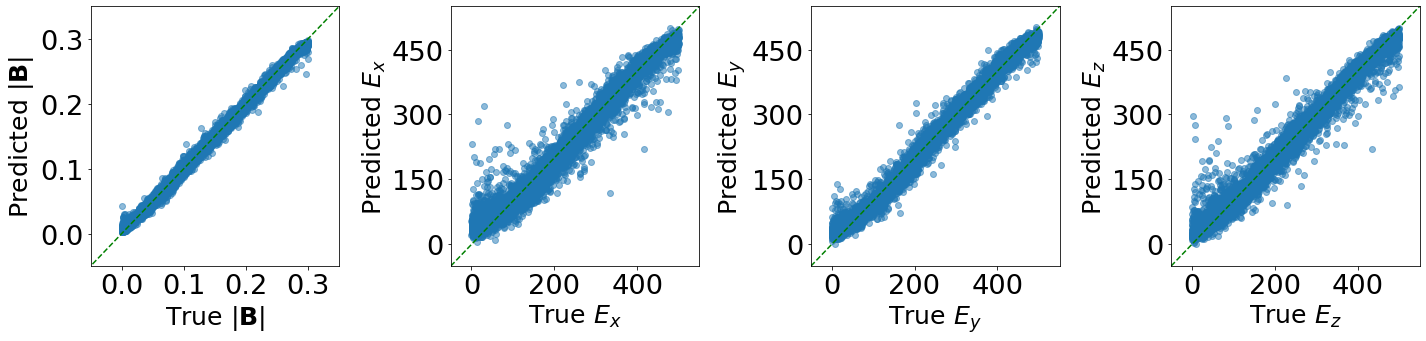

Training set evaluation done.


In [36]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import os

# Define a global font scaling factor
scale = 2.1

# Base font sizes
base_label = 12
base_suptitle = 14
base_ticks = 13

plt.figure(figsize=(20, 5))

# --- B3 ---
ax1 = plt.subplot(1, 4, 1)
ax1.scatter(B_true_train, B_pred_train, alpha=0.5)
ax1.plot([-0.1, 1.1], [-0.1, 1.1], 'g--')
ax1.set_xlim(-0.05, 0.35)
ax1.set_ylim(-0.05, 0.35)
ax1.set_xlabel('True $|\\mathbf{B}|$', fontsize=base_label*scale)
ax1.set_ylabel('Predicted $|\\mathbf{B}|$', fontsize=base_label*scale)
ax1.tick_params(labelsize=base_ticks*scale)
# Reduce x ticks only for the first subplot
ax1.xaxis.set_major_locator(ticker.MaxNLocator(nbins=4))
# Reduce y ticks
ax1.yaxis.set_major_locator(ticker.MaxNLocator(nbins=4))

# --- E1 ---
ax2 = plt.subplot(1, 4, 2)
ax2.scatter(E_true_train[:, 0], E_pred_train[:, 0], alpha=0.5)
ax2.plot([-50, 550], [-50, 550], 'g--')
ax2.set_xlim(-50, 550)
ax2.set_ylim(-50, 550)
ax2.set_xlabel('True $E_x$', fontsize=base_label*scale)
ax2.set_ylabel('Predicted $E_x$', fontsize=base_label*scale)
ax2.tick_params(labelsize=base_ticks*scale)
# Reduce y ticks
ax2.yaxis.set_major_locator(ticker.MaxNLocator(nbins=4))
# ax2.ticklabel_format(style='sci', axis='both', scilimits=(0,0))
# ax2.xaxis.get_offset_text().set_fontsize(base_ticks*scale*0.8)
# ax2.yaxis.get_offset_text().set_fontsize(base_ticks*scale*0.8)


# --- E2 ---
ax3 = plt.subplot(1, 4, 3)
ax3.scatter(E_true_train[:, 1], E_pred_train[:, 1], alpha=0.5)
ax3.plot([-50, 550], [-50, 550], 'g--')
ax3.set_xlim(-50, 550)
ax3.set_ylim(-50, 550)
ax3.set_xlabel('True $E_y$', fontsize=base_label*scale)
ax3.set_ylabel('Predicted $E_y$', fontsize=base_label*scale)
ax3.tick_params(labelsize=base_ticks*scale)
# Reduce y ticks
ax3.yaxis.set_major_locator(ticker.MaxNLocator(nbins=4))
# ax3.ticklabel_format(style='sci', axis='both', scilimits=(0,0))
# ax3.xaxis.get_offset_text().set_fontsize(base_ticks*scale*0.8)
# ax3.yaxis.get_offset_text().set_fontsize(base_ticks*scale*0.8)

# --- E3 ---
ax4 = plt.subplot(1, 4, 4)
ax4.scatter(E_true_train[:, 2], E_pred_train[:, 2], alpha=0.5)
ax4.plot([-50, 550], [-50, 550], 'g--')
ax4.set_xlim(-50, 550)
ax4.set_ylim(-50, 550)
ax4.set_xlabel('True $E_z$', fontsize=base_label*scale)
ax4.set_ylabel('Predicted $E_z$', fontsize=base_label*scale)
ax4.tick_params(labelsize=base_ticks*scale)
# Reduce y ticks
ax4.yaxis.set_major_locator(ticker.MaxNLocator(nbins=4))
# ax4.ticklabel_format(style='sci', axis='both', scilimits=(0,0))
# ax4.xaxis.get_offset_text().set_fontsize(base_ticks*scale*0.8)
# ax4.yaxis.get_offset_text().set_fontsize(base_ticks*scale*0.8)

# Figure title
# plt.suptitle('True vs. Predicted Components Using GBR-Hist (Training Data)', fontsize=base_suptitle*scale)

# Layout & save
plt.tight_layout(rect=[0, 0, 1, 0.97])
figure_train_file = os.path.join("/home/botingl/machine learning copy/Plots", 
                                 generate_filename("true_vs_predictions_train", "pdf"))
plt.savefig(figure_train_file, dpi=300, facecolor='white')
plt.show()

print("Training set evaluation done.", flush=True)


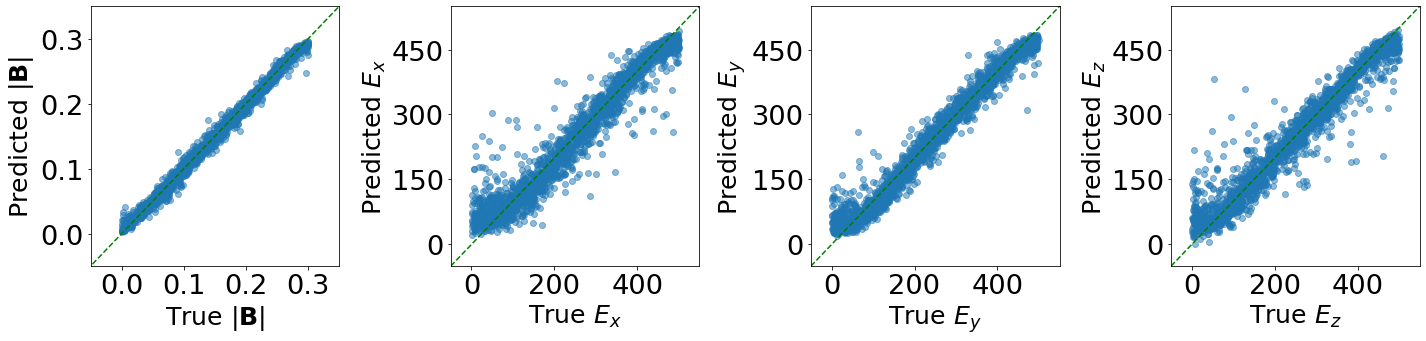

Testing set evaluation done.


In [37]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import os

# Define a global font scaling factor
scale = 2.1 

# Base font sizes
base_label = 12
base_suptitle = 14
base_ticks = 13

plt.figure(figsize=(20, 5))

# --- B3 ---
ax1 = plt.subplot(1, 4, 1)
ax1.scatter(B_true_test, B_pred_test, alpha=0.5)
ax1.plot([-0.1, 1.1], [-0.1, 1.1], 'g--')
ax1.set_xlim(-0.05, 0.35)
ax1.set_ylim(-0.05, 0.35)
ax1.set_xlabel('True $|\mathbf{B}|$', fontsize=base_label*scale)
ax1.set_ylabel('Predicted $|\mathbf{B}|$', fontsize=base_label*scale)
ax1.tick_params(labelsize=base_ticks*scale)
# Reduce x ticks only for the first subplot
ax1.xaxis.set_major_locator(ticker.MaxNLocator(nbins=4))
# Reduce y ticks
ax1.yaxis.set_major_locator(ticker.MaxNLocator(nbins=4))

# --- E1 ---
ax2 = plt.subplot(1, 4, 2)
ax2.scatter(E_true_test[:, 0], E_pred_test[:, 0], alpha=0.5)
ax2.plot([-50, 550], [-50, 550], 'g--')
ax2.set_xlim(-50, 550)
ax2.set_ylim(-50, 550)
ax2.set_xlabel('True $E_x$', fontsize=base_label*scale)
ax2.set_ylabel('Predicted $E_x$', fontsize=base_label*scale)
ax2.tick_params(labelsize=base_ticks*scale)
# Reduce y ticks
ax2.yaxis.set_major_locator(ticker.MaxNLocator(nbins=4))
# ax2.ticklabel_format(style='sci', axis='both', scilimits=(0,0))
# ax2.xaxis.get_offset_text().set_fontsize(base_ticks*scale*0.8)
# ax2.yaxis.get_offset_text().set_fontsize(base_ticks*scale*0.8)

# --- E2 ---
ax3 = plt.subplot(1, 4, 3)
ax3.scatter(E_true_test[:, 1], E_pred_test[:, 1], alpha=0.5)
ax3.plot([-50, 550], [-50, 550], 'g--')
ax3.set_xlim(-50, 550)
ax3.set_ylim(-50, 550)
ax3.set_xlabel('True $E_y$', fontsize=base_label*scale)
ax3.set_ylabel('Predicted $E_y$', fontsize=base_label*scale)
ax3.tick_params(labelsize=base_ticks*scale)
# Reduce y ticks
ax3.yaxis.set_major_locator(ticker.MaxNLocator(nbins=4))
# ax3.ticklabel_format(style='sci', axis='both', scilimits=(0,0))
# ax3.xaxis.get_offset_text().set_fontsize(base_ticks*scale*0.8)
# ax3.yaxis.get_offset_text().set_fontsize(base_ticks*scale*0.8)


# --- E3 ---
ax4 = plt.subplot(1, 4, 4)
ax4.scatter(E_true_test[:, 2], E_pred_test[:, 2], alpha=0.5)
ax4.plot([-50, 550], [-50, 550], 'g--')
ax4.set_xlim(-50, 550)
ax4.set_ylim(-50, 550)
ax4.set_xlabel('True $E_z$', fontsize=base_label*scale)
ax4.set_ylabel('Predicted $E_z$', fontsize=base_label*scale)
ax4.tick_params(labelsize=base_ticks*scale)
# Reduce y ticks
ax4.yaxis.set_major_locator(ticker.MaxNLocator(nbins=4))
# ax4.ticklabel_format(style='sci', axis='both', scilimits=(0,0))
# ax4.xaxis.get_offset_text().set_fontsize(base_ticks*scale*0.8)
# ax4.yaxis.get_offset_text().set_fontsize(base_ticks*scale*0.8)


# Figure title
# plt.suptitle('True vs. Predicted Components Using GBR-Hist (Testing Data)',fontsize=base_suptitle*scale)

# Layout & save
plt.tight_layout(rect=[0, 0, 1, 0.97])
figure_test_file = os.path.join("/home/botingl/machine learning copy/Plots", generate_filename("true_vs_predictions_test", "pdf"))
plt.savefig(figure_test_file, dpi=300, facecolor='white')
plt.show()

print("Testing set evaluation done.", flush=True)


In [38]:
print("Testing set evaluation done.", flush=True)

Testing set evaluation done.


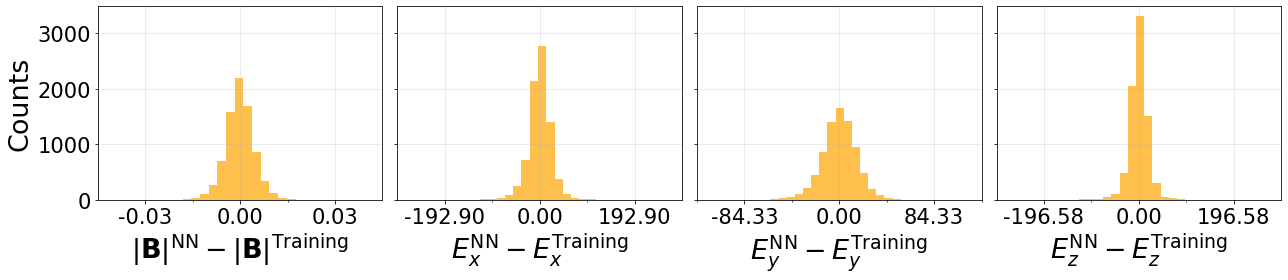

In [39]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.ticker import FormatStrFormatter

# Adjustable font sizes
scale = 1.5
label_fontsize = int(18 * scale)
tick_fontsize  = int(14 * scale)

# Errors (assumed already defined)
B3_error_train = B_true_train - B_pred_train
E1_error_train = E_true_train[:, 0] - E_pred_train[:, 0]
E2_error_train = E_true_train[:, 1] - E_pred_train[:, 1]
E3_error_train = E_true_train[:, 2] - E_pred_train[:, 2]

data_list = [
    (B3_error_train, r'$|\mathbf{B}|^{\mathrm{NN}} - |\mathbf{B}|^{\mathrm{Training}}$'),
    (E1_error_train, r'$E_x^{\mathrm{NN}} - E_x^{\mathrm{Training}}$'),
    (E2_error_train, r'$E_y^{\mathrm{NN}} - E_y^{\mathrm{Training}}$'),
    (E3_error_train, r'$E_z^{\mathrm{NN}} - E_z^{\mathrm{Training}}$')
]

fig, axs = plt.subplots(1, 4, figsize=(18, 4), sharey=True)

for i, (data, xlabel) in enumerate(data_list):
    ax = axs[i]
    ax.hist(data, bins=30, color='orange', alpha=0.7)
    ax.set_xlabel(xlabel, fontsize=label_fontsize)
    if i == 0:
        ax.set_ylabel('Counts', fontsize=label_fontsize)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='both', which='both', labelsize=tick_fontsize)

    # --- force symmetry around zero, subplot by subplot ---
    lim = np.max(np.abs([data.min(), data.max()]))
    ax.set_xlim(-lim, lim)

    # Make x ticks denser: about 6–8 major ticks
    step = (2 * lim) / 3.0
    ax.xaxis.set_major_locator(ticker.MultipleLocator(step))
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(2))

    # --- format x ticks with two decimals ---
    ax.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))


plt.tight_layout()
plt.savefig("/home/botingl/machine learning copy/Plots/GBM_Hist_testing_histogram.pdf", dpi=300, facecolor='white')
plt.show()


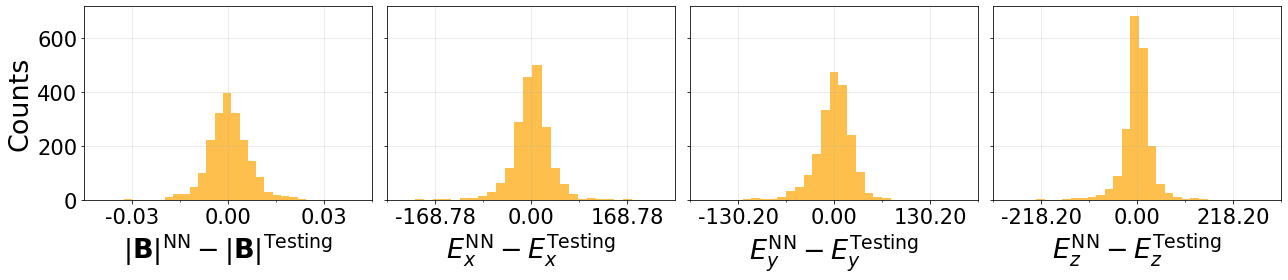

In [40]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.ticker import FormatStrFormatter

# Adjustable font sizes
scale = 1.5
label_fontsize = int(18 * scale)
tick_fontsize  = int(14 * scale)

# Errors (assumed already defined)
B3_error_test = B_true_test - B_pred_test
E1_error_test = E_true_test[:, 0] - E_pred_test[:, 0]
E2_error_test = E_true_test[:, 1] - E_pred_test[:, 1]
E3_error_test = E_true_test[:, 2] - E_pred_test[:, 2]

data_list = [
    (B3_error_test, r'$|\mathbf{B}|^{\mathrm{NN}} - |\mathbf{B}|^{\mathrm{Testing}}$'),
    (E1_error_test, r'$E_x^{\mathrm{NN}} - E_x^{\mathrm{Testing}}$'),
    (E2_error_test, r'$E_y^{\mathrm{NN}} - E_y^{\mathrm{Testing}}$'),
    (E3_error_test, r'$E_z^{\mathrm{NN}} - E_z^{\mathrm{Testing}}$')
]

fig, axs = plt.subplots(1, 4, figsize=(18, 4), sharey=True)

for i, (data, xlabel) in enumerate(data_list):
    ax = axs[i]
    ax.hist(data, bins=30, color='orange', alpha=0.7)
    ax.set_xlabel(xlabel, fontsize=label_fontsize)
    if i == 0:
        ax.set_ylabel('Counts', fontsize=label_fontsize)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='both', which='both', labelsize=tick_fontsize)

    # --- force symmetry around zero, subplot by subplot ---
    lim = np.max(np.abs([data.min(), data.max()]))
    ax.set_xlim(-lim, lim)

    # Make x ticks denser: about 6–8 major ticks
    step = (2 * lim) / 3.0
    ax.xaxis.set_major_locator(ticker.MultipleLocator(step))
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(2))

    # --- format x ticks with two decimals ---
    ax.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))


plt.tight_layout()
plt.savefig("/home/botingl/machine learning copy/Plots/GBM_Hist_training_histogram.pdf", dpi=300, facecolor='white')
plt.show()
